In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import sys
sys.path.insert(0, str(Path.home() / "PMF-MHD-recomb"))
sys.path.insert(0, str(Path.home() / "PMF-MHD-recomb/src"))
sys.path.insert(0, str(Path.home() / "PMF-MHD-recomb/data"))

from pmhd import pars, cons
from pmhd.data.grids import (
    k_grid,
    theta_grid,
    z_grid,
    load_or_generate_z_arrays,
    load_or_generate_B0arr, 
eps_grid
)

In [2]:
karr = k_grid()
thetaarr = theta_grid()
epsarr = eps_grid()
zcrossarr, zfsarr = load_or_generate_z_arrays()

In [3]:
B0arr = load_or_generate_B0arr()


In [4]:
file_path = Path.home() / "PMF-MHD-recomb/data/outputs/Tfs/B_79pG/TCRalf_k41.npy"
TCRtest = np.load(file_path)


In [5]:
file_path = Path.home() / "PMF-MHD-recomb/data/outputs/Tfs/B_79pG/TCRalf_k41.npy"

file_path2 = Path.home() / "lib/PRD/save/Tfs/B_79pG/TCRalf_k41.npy"

TCRtest = np.load(file_path)
TCRtest2 = np.load(file_path2)
kind = 41
zplot = np.logspace(np.log10(zcrossarr[kind]),np.log10(zfsarr[kind]),num = 10**4)
# zplot = np.logspace(np.log10(1900),np.log10(600),num = 10**4)

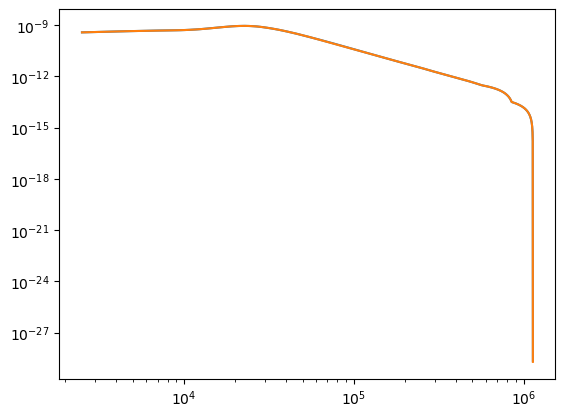

In [6]:
thetaind = 8
# plt.loglog(zplot, abs((TCRtest-TCRtest2)/TCRtest)[thetaind,0])
plt.loglog(zplot, abs(TCRtest[thetaind,0]) )
plt.loglog(zplot, abs(TCRtest2[thetaind,0]))


In [7]:
file_path = Path.home() / "PMF-MHD-recomb/data/outputs/Tfs/B_79pG/FSRsahaalf_k41.npy"

file_path2 = Path.home() / "lib/PRD/save/Tfs/B_79pG/FSRsahaalf_k41.npy"

sahatest = np.load(file_path)
sahatest2 = np.load(file_path2)
kind = 41
zplot = np.logspace(np.log10(zfsarr[kind]),np.log10(600),num = 10**4)


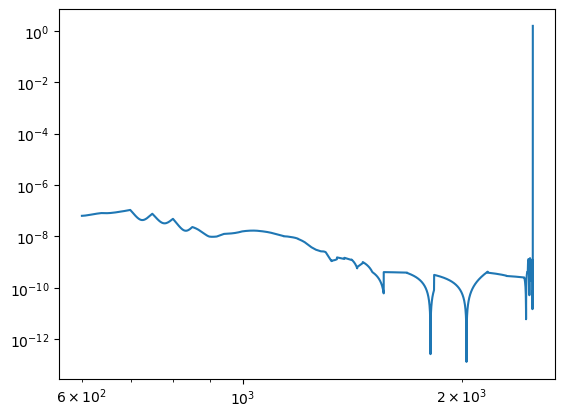

In [8]:
thetaind = 8
plt.loglog(zplot, abs((sahatest-sahatest2)/sahatest)[thetaind,0])
# plt.semilogx(zplot, sahatest2[thetaind,0])

In [9]:
file_path = Path.home() / "PMF-MHD-recomb/data/outputs/Tfs/B_79pG/FSRTLAmag_k41.npy"

file_path2 = Path.home() / "lib/PRD/save/fullk/Tfs/B_79pG/FSRTLAmag_k41.npy"

TLAtest = np.load(file_path)
TLAtest2 = np.load(file_path2)
kind = 1
zplot = np.logspace(np.log10(1900),np.log10(600),num = 10**4)


In [10]:
TLAtesthold = np.zeros((33,10**4))
TLAtesthold2 = np.zeros((33,10**4))
TLAtesthold[:17] = TLAtest[:,0]
TLAtesthold2[:17] = TLAtest2[:,0]
for i in range(int((len(thetaarr)-1)/2)+1):
    TLAtesthold[-i+int((len(thetaarr)-1))] = TLAtesthold[i]
    TLAtesthold2[-i+int((len(thetaarr)-1))] = TLAtesthold2[i]

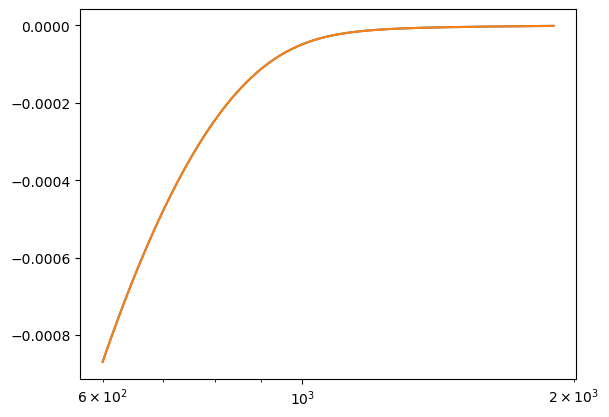

In [11]:
thetaind = 4
# plt.loglog(zplot, abs((TLAtest-TLAtest2)/TLAtest)[thetaind,0])
plt.semilogx(zplot, TLAtest[thetaind,0])
plt.semilogx(zplot, TLAtest2[thetaind,0])

In [12]:
zind = 500
file_path = Path.home() / f"PMF-MHD-recomb/data/outputs/fbars/test/f1bars/bbar_zchunk{zind}.npy"

file_path2 = Path.home() / f"lib/PRD/save/fullk/f1bars/bbar_zchunk{zind}.npy"

abartest = np.load(file_path)
abartest2 = np.load(file_path2)


FileNotFoundError: [Errno 2] No such file or directory: '/home/jonschiff/PMF-MHD-recomb/data/outputs/fbars/test/f1bars/bbar_zchunk500.npy'

In [13]:
# plt.loglog(karr, abs((abartest2-abartest)/abartest2))
plt.loglog(karr, abs(abartest))
plt.loglog(karr, abs(abartest2))

NameError: name 'abartest' is not defined

In [14]:
import pickle

file_path = Path.home() / f"PMF-MHD-recomb/data/outputs/fbars/test/f2bars_dict/f2bars_p1_dict_zch_{zind}.pkl"
file_path2 = Path.home() / f"lib/PRD/save/fullk/f2bars_dict/f2bars_p1_dict_zch_{zind}.pkl"

with open(str(file_path), 'rb') as f:
    f2bars_m1_dict = pickle.load(f)

with open(str(file_path2), 'rb') as f:
    f2bars_m1_dict2 = pickle.load(f)


FileNotFoundError: [Errno 2] No such file or directory: '/home/jonschiff/PMF-MHD-recomb/data/outputs/fbars/test/f2bars_dict/f2bars_p1_dict_zch_500.pkl'

In [15]:
plt.loglog(karr,abs(f2bars_m1_dict['dx_mom2_total'][:,0]))
plt.loglog(karr,abs(f2bars_m1_dict2['dx_mom2_total'][:,0]))

NameError: name 'f2bars_m1_dict' is not defined

In [16]:
import pickle
bind = 40; kind = 43
OUTBASE = Path.home() / "PMF-MHD-recomb/data/outputs"
ang_avg_TLA = OUTBASE/f"ang_avg/TLA/B_{round(1e12*B0arr[bind])}pG"

with open(ang_avg_TLA/f'ang_avg_k{kind}.pkl', 'rb') as f:
        ang_avg_dict = pickle.load(f) 

bind = 40
ang_avg_PRD = {}
for k in [
        'bxbxbar', 'bybybar', 'PhixPhixbar',
        'PhiyPhiybar', 'ThetaThetabar', 'PhiyThetabar',
        'deltamThetabar', 'deltamdeltambar', 'xexebar', 'xedeltambar', 'xeThetabar',
        'PhixPhixprimebar', 'PhiyPhiyprimebar', 'ThetaThetaprimebar'
    ]: 
        ang_avg_PRD[k] = np.load(Path.home()/f'lib/PRD/save/fullk/ang_avg/B_{round(1e12*B0arr[bind])}pG/TLA/{k}_k{kind}.npy')

In [17]:
bind = 40; epsind = 9

source_fncs = OUTBASE/"source_fncs"
cross_corrload = OUTBASE/"cross_corr"
with open(cross_corrload/f'cross_corr_B_{round(1e12*B0arr[bind])}pG_e{round(epsarr[epsind],3)}.pkl', 'rb') as f:
    cross_corr = pickle.load(f)

ftot = np.load(source_fncs/f'ftot_B_{round(1e12*B0arr[bind])}pG_e{round(epsarr[epsind],3)}.npy')

ftot2 = np.load(Path.home()/f'lib/PRD/save/fullk/source_fncs/ftot_B_{round(1e12*B0arr[bind])}pG_e{round(epsarr[epsind],3)}.npy')     
with open(Path.home()/f'lib/PRD/save/fullk/cross_corr/cross_corr_B_{round(1e12*B0arr[bind])}pG_e{round(epsarr[epsind],3)}.pkl', 'rb') as f:
    cross_corr2 = pickle.load(f) 


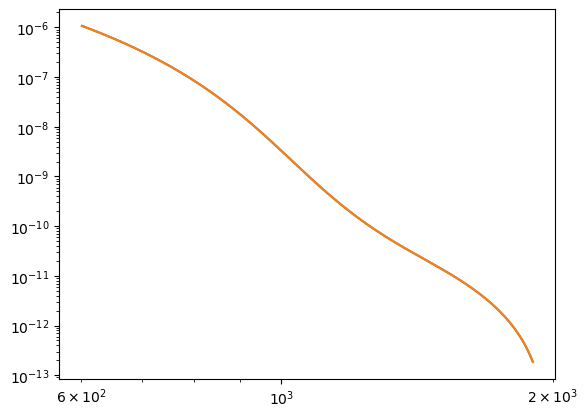

In [18]:
zarr = z_grid()
plt.loglog(zarr, ang_avg_dict['deltamdeltambar'])
plt.loglog(zarr, ang_avg_PRD['deltamdeltambar'])

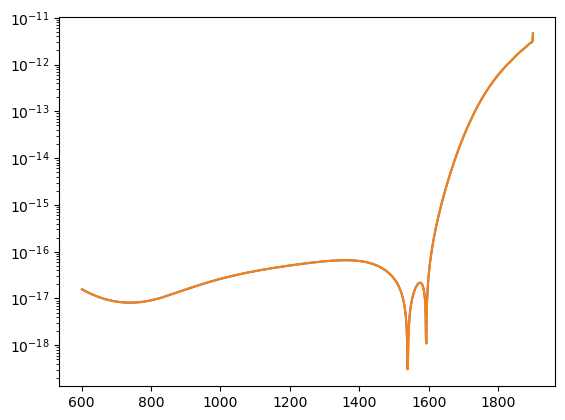

In [19]:
plt.semilogy(zarr,abs(ftot))
plt.semilogy(zarr,abs(ftot2))

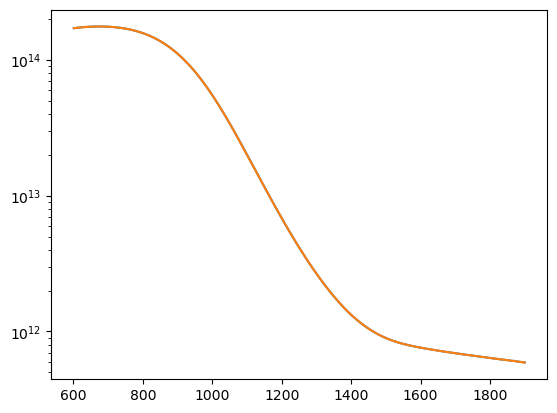

In [20]:
plt.semilogy(zarr, cross_corr['vxrms'])
plt.semilogy(zarr, cross_corr2['vxrms'])

In [24]:
xe2direc = OUTBASE/"xe2"

xe2 = np.load(xe2direc/f'xe2_B_{round(1e12*B0arr[bind])}pG_e{round(epsarr[epsind],3)}.npy')
xe2_old = np.load(Path.home()/f'lib/PRD/save/fullk/xe2/xe2_B_{round(1e12*B0arr[bind])}pG_e{round(epsarr[epsind],3)}.npy')


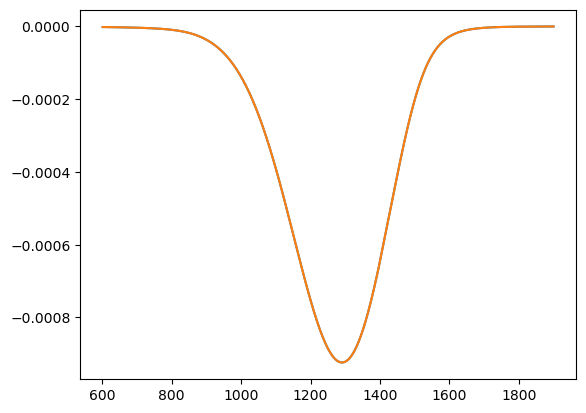

In [25]:
plt.plot(zarr,xe2)
plt.plot(zarr,xe2_old)

In [ ]:
size_bytes = file_path2.stat().st_size
print(size_bytes, "bytes")

4945 bytes


In [213]:
file_hold = Path.home() / f"lib/PRD/save/fullk/f2bars_dict"
size_bytes = file_hold.stat().st_size
print(size_bytes/1e6, "MB")

0.233472 MB


In [ ]:
/home/jonschiff/lib/PRD/save/fullk/visib/dtau2_B_5pGe-0.1.npy
/home/jonschiff/lib/PRD/save/fullk/visib/visibprefactor_B_20pGe-0.14.npy

array([1900, 1899, 1898, ...,  603,  602,  601], shape=(1300,))

In [30]:
visibdirec = OUTBASE/"visib"

visib = np.load(visibdirec/f'visib_B_{round(1e12*B0arr[bind])}pG_e{round(epsarr[epsind],3)}.npy')
visibold_old = np.load(Path.home()/f'lib/PRD/save/fullk/visib/visibprefactor_B_{round(1e12*B0arr[bind])}pGe{round(epsarr[epsind],3)}.npy')


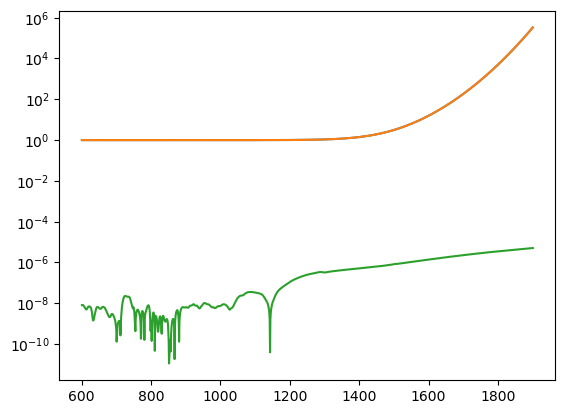

In [ ]:
plt.semilogy(zarr,visib)
plt.semilogy(zarr,visibold_old)
# plt.semilogy(zarr,abs(visibold_old - visib)/visib)